# LIBRERIAS

In [4]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
import SimpleITK as sitk
from torchvision import transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split

In [21]:
BASE_DIR = "C:/CAPSTONE"
DATA_PATH = "C:/Capstone/data"
MODEL_PATH = "C:/Capstone/best_ResNet18+LSTM.pth"
REMAINING_PATH = "C:/Capstone/remaining_candidates.csv"
POSITIVAS_LISTA = "C:/CAPSTONE/2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro/positivas.txt"
NEGATIVAS_LISTA = "C:/CAPSTONE/2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro/negativas.txt"
RESULTADOS_DIR = "C:/CAPSTONE/resultados"

os.makedirs(RESULTADOS_DIR, exist_ok=True)

In [ ]:
carpetas = [
    "2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro",
    "2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM",
    "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/entrenamiento",
    "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/validacion",
    "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/prueba",
    "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/entrenamiento",
    "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/validacion",
    "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/prueba"
]

for carpeta in carpetas:
    os.makedirs(os.path.join(BASE_DIR, carpeta), exist_ok=True)

print("Carpetas creadas")

Carpetas creadas


In [ ]:
remaining = pd.read_csv(REMAINING_PATH)

# IDENTIFICAR TOMOGRAFÍAS CON NÓDULOS (positivas) y SIN NÓDULOS (negativas PURAS)
# Una tomografía es NEGATIVA PURA si TODAS sus anotaciones son class=0
tomografias_con_nodulos = set(remaining[remaining['class'] == 1]['seriesuid'].unique())

# Encontrar tomografías que NO tienen NINGUNA anotación positiva
todas_tomografias = set(remaining['seriesuid'].unique())
tomografias_sin_nodulos = todas_tomografias - tomografias_con_nodulos

# Verificar que las negativas puras NO tienen anotaciones positivas
print(f"   Tomografías con nódulos: {len(tomografias_con_nodulos)}")
print(f"   Tomografías sin nódulos (puras): {len(tomografias_sin_nodulos)}")
print(f"   Total: {len(tomografias_con_nodulos) + len(tomografias_sin_nodulos)}")

# Opcional: Verificar que no hay solapamiento
interseccion = tomografias_con_nodulos & tomografias_sin_nodulos
if interseccion:
    print(f"   ADVERTENCIA: {len(interseccion)} tomografías están en ambas listas")
    print(f"   Esto NO debería pasar. Revisa tus datos.")

   Tomografías con nódulos: 78
   Tomografías sin nódulos (puras): 704
   Total: 782


In [ ]:
def guardar_lista(tomografias, carpeta, nombre="lista.txt"):
    if not tomografias:
        print(f"   Lista vacía en {carpeta}")
        return
    ruta = os.path.join(BASE_DIR, carpeta, nombre)
    with open(ruta, 'w') as f:
        for t in tomografias:
            f.write(f"{t}\n")
    print(f"   Guardado: {len(tomografias)} tomografías en {carpeta}")

In [ ]:
positivas = list(tomografias_con_nodulos)
print(f"\nDIVISIÓN DE TOMOGRAFÍAS POSITIVAS ({len(positivas)} totales):")

# A. Validación DL Puro (60% de las positivas)
dl_puro_pos, resto_pos = train_test_split(positivas, test_size=0.4, random_state=42)
print(f"   Validación DL Puro (positivas): {len(dl_puro_pos)}")

# B. GradCAM (20 positivas como muestra)
gradcam_pos = resto_pos[:20] if len(resto_pos) >= 20 else resto_pos
resto_pos = [t for t in resto_pos if t not in gradcam_pos]
print(f"   GradCAM (positivas): {len(gradcam_pos)}")

# C/D. Sistema Híbrido (el resto)
train_pos, temp_pos = train_test_split(resto_pos, test_size=0.4, random_state=42)
val_pos, test_pos = train_test_split(temp_pos, test_size=0.5, random_state=42)
print(f"   Sistema Híbrido (positivas): {len(train_pos)} train + {len(val_pos)} val + {len(test_pos)} test")


DIVISIÓN DE TOMOGRAFÍAS POSITIVAS (78 totales):
   Validación DL Puro (positivas): 46
   GradCAM (positivas): 20
   Sistema Híbrido (positivas): 7 train + 2 val + 3 test


In [ ]:
negativas = list(tomografias_sin_nodulos)
print(f"\nDIVISIÓN DE TOMOGRAFÍAS NEGATIVAS PURAS ({len(negativas)} totales):")

# A. Validación DL Puro (misma proporción que positivas)
dl_puro_neg, resto_neg = train_test_split(negativas, test_size=0.4, random_state=42)
print(f"   Validación DL Puro (negativas): {len(dl_puro_neg)}")

# B. GradCAM (20 negativas como muestra)
gradcam_neg = resto_neg[:20] if len(resto_neg) >= 20 else resto_neg
resto_neg = [t for t in resto_neg if t not in gradcam_neg]
print(f"   GradCAM (negativas): {len(gradcam_neg)}")

# C/D. Sistema Híbrido (el resto)
train_neg, temp_neg = train_test_split(resto_neg, test_size=0.4, random_state=42)
val_neg, test_neg = train_test_split(temp_neg, test_size=0.5, random_state=42)
print(f"   Sistema Híbrido (negativas): {len(train_neg)} train + {len(val_neg)} val + {len(test_neg)} test")


DIVISIÓN DE TOMOGRAFÍAS NEGATIVAS PURAS (704 totales):
   Validación DL Puro (negativas): 422
   GradCAM (negativas): 20
   Sistema Híbrido (negativas): 157 train + 52 val + 53 test


In [ ]:
print("\nVERIFICANDO INTEGRIDAD DE SPLITS:")

def verificar_solapamiento(lista1, lista2, nombre1, nombre2):
    solapamiento = set(lista1) & set(lista2)
    if solapamiento:
        print(f"   ERROR: {nombre1} y {nombre2} comparten {len(solapamiento)} tomografías")
        return False
    else:
        print(f"   OK: {nombre1} y {nombre2} no se solapan")
        return True

# Verificar que no hay solapamiento entre grupos de positivas
verificar_solapamiento(dl_puro_pos, gradcam_pos, "Validación_Pos", "GradCAM_Pos")
verificar_solapamiento(dl_puro_pos, train_pos, "Validación_Pos", "Train_Pos")
verificar_solapamiento(dl_puro_pos, val_pos, "Validación_Pos", "Val_Pos")
verificar_solapamiento(dl_puro_pos, test_pos, "Validación_Pos", "Test_Pos")
verificar_solapamiento(gradcam_pos, train_pos, "GradCAM_Pos", "Train_Pos")
verificar_solapamiento(train_pos, val_pos, "Train_Pos", "Val_Pos")
verificar_solapamiento(train_pos, test_pos, "Train_Pos", "Test_Pos")

print("-" * 50)

verificar_solapamiento(dl_puro_neg, gradcam_neg, "Validación_Neg", "GradCAM_Neg")
verificar_solapamiento(dl_puro_neg, train_neg, "Validación_Neg", "Train_Neg")
verificar_solapamiento(train_neg, val_neg, "Train_Neg", "Val_Neg")
verificar_solapamiento(train_neg, test_neg, "Train_Neg", "Test_Neg")


VERIFICANDO INTEGRIDAD DE SPLITS:
   OK: Validación_Pos y GradCAM_Pos no se solapan
   OK: Validación_Pos y Train_Pos no se solapan
   OK: Validación_Pos y Val_Pos no se solapan
   OK: Validación_Pos y Test_Pos no se solapan
   OK: GradCAM_Pos y Train_Pos no se solapan
   OK: Train_Pos y Val_Pos no se solapan
   OK: Train_Pos y Test_Pos no se solapan
--------------------------------------------------
   OK: Validación_Neg y GradCAM_Neg no se solapan
   OK: Validación_Neg y Train_Neg no se solapan
   OK: Train_Neg y Val_Neg no se solapan
   OK: Train_Neg y Test_Neg no se solapan


True

In [ ]:
# Validación DL Puro
guardar_lista(dl_puro_pos, "2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro", "positivas.txt")
guardar_lista(dl_puro_neg, "2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro", "negativas.txt")

# GradCAM
guardar_lista(gradcam_pos, "2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM", "positivas.txt")
guardar_lista(gradcam_neg, "2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM", "negativas.txt")

# Sistema Híbrido DL
guardar_lista(train_pos, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/entrenamiento", "positivas.txt")
guardar_lista(train_neg, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/entrenamiento", "negativas.txt")
guardar_lista(val_pos, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/validacion", "positivas.txt")
guardar_lista(val_neg, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/validacion", "negativas.txt")
guardar_lista(test_pos, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/prueba", "positivas.txt")
guardar_lista(test_neg, "2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/prueba", "negativas.txt")

# Sistema Híbrido DL+ML (mismas listas que DL)
guardar_lista(train_pos, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/entrenamiento", "positivas.txt")
guardar_lista(train_neg, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/entrenamiento", "negativas.txt")
guardar_lista(val_pos, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/validacion", "positivas.txt")
guardar_lista(val_neg, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/validacion", "negativas.txt")
guardar_lista(test_pos, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/prueba", "positivas.txt")
guardar_lista(test_neg, "2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/prueba", "negativas.txt")

   Guardado: 46 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro
   Guardado: 422 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/A_Validacion_DL_Puro
   Guardado: 20 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM
   Guardado: 20 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM
   Guardado: 7 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/entrenamiento
   Guardado: 157 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/entrenamiento
   Guardado: 2 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/validacion
   Guardado: 52 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/validacion
   Guardado: 3 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/prueba
   Guardado: 53 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/C_Sistema_Hibrido_DL/prueba
   Guardado: 7 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/entrenamiento
   Guardado: 157 tomografías en 2_TOMOGRAFIAS_POR_PRUEBA/D_Sistema_Hibrido_DL_ML/entrenamiento
 


Dispositivo: cpu
Modelo cargado correctamente
Candidatos totales en validación: 93825
Positivos (class=1): 68
Negativos (class=0): 93757
Negativos muestreados (1 por tomografía): 468
Candidatos balanceados a evaluar: 536
Procesados 100/536 | Última prob=0.0380
Procesados 200/536 | Última prob=0.0055
Procesados 300/536 | Última prob=0.0021
Procesados 400/536 | Última prob=0.0063
Procesados 500/536 | Última prob=0.0031

RESULTADOS GENERALES
TP: 63, FN: 5, TN: 437, FP: 31
Sensibilidad: 0.9265
Especificidad: 0.9338
Accuracy: 0.9328
ROC-AUC: 0.9692

SENSIBILIDAD POR TAMAÑO
<5 mm: 0.7500 (4 nodulos)
5-10 mm: 0.8750 (24 nodulos)
>10 mm: 0.9756 (41 nodulos)

Resultados guardados en: C:/CAPSTONE/resultados\validacion_remaining_candidates_balanceado.csv


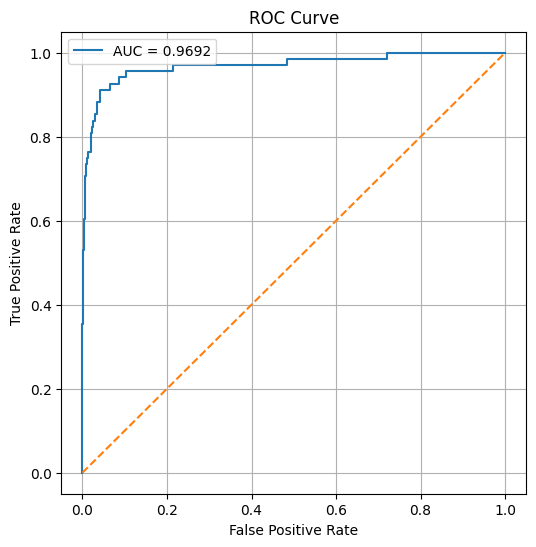

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import cv2
import SimpleITK as sitk
import os
import matplotlib.pyplot as plt
from tqdm import tqdm  # para barra de progreso opcional

# ============================================
# PASO 2: Definir la arquitectura del modelo (igual que antes)
# ============================================
class ResNet18LSTM(nn.Module):
    def __init__(self, num_classes=1, lstm_hidden=256, num_layers=2, dropout=0.2):
        super(ResNet18LSTM, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        self.lstm = nn.LSTM(in_features, lstm_hidden, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        features = self.resnet(x)
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(features)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output.squeeze(1)

# ============================================
# PASO 3: Cargar modelo entrenado
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {device}")

model = ResNet18LSTM().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Modelo cargado correctamente")

# ============================================
# PASO 5: Buscar tomografía en subsets
# ============================================
def encontrar_tomografia(seriesuid):
    for subset in range(10):
        mhd_path = os.path.join(DATA_PATH, f"subset{subset}", f"{seriesuid}.mhd")
        if os.path.exists(mhd_path):
            return mhd_path
    return None

# ============================================
# PASO 6: Extraer patch 3D (con validación de bordes)
# ============================================
def extraer_patch_desde_tomografia(
    mhd_path,
    coordX,
    coordY,
    coordZ,
    hu_min=-1000,
    hu_max=400,
    patch_size=64
):
    sitk_img = sitk.ReadImage(mhd_path)
    volume = sitk.GetArrayFromImage(sitk_img)
    # Convertir coordenadas físicas (mm) a índice de vóxel
    idx = sitk_img.TransformPhysicalPointToIndex((coordX, coordY, coordZ))
    voxelX, voxelY, voxelZ = idx[0], idx[1], idx[2]

    # Validar que los índices estén dentro del volumen
    if not (0 <= voxelZ < volume.shape[0] and 0 <= voxelY < volume.shape[1] and 0 <= voxelX < volume.shape[2]):
        raise ValueError(f"Coordenadas fuera de rango: ({voxelZ},{voxelY},{voxelX}) vs {volume.shape}")

    half = patch_size // 2
    z_start = max(0, voxelZ - half)
    z_end = min(volume.shape[0], voxelZ + half)
    y_start = max(0, voxelY - half)
    y_end = min(volume.shape[1], voxelY + half)
    x_start = max(0, voxelX - half)
    x_end = min(volume.shape[2], voxelX + half)

    if z_start >= z_end or y_start >= y_end or x_start >= x_end:
        raise ValueError("Intervalo vacío en alguna dimensión")

    patch_hu = volume[z_start:z_end, y_start:y_end, x_start:x_end].astype(np.float32)
    patch_clipped = np.clip(patch_hu, hu_min, hu_max)
    patch_norm = (patch_clipped - hu_min) / (hu_max - hu_min)

    if patch_norm.shape != (patch_size, patch_size, patch_size):
        temp = np.zeros((patch_size, patch_size, patch_size), dtype=np.float32)
        temp[:patch_norm.shape[0], :patch_norm.shape[1], :patch_norm.shape[2]] = patch_norm
        patch_norm = temp

    return patch_norm
# ============================================
# PASO 7: Convertir patch a secuencia (igual)
# ============================================
def patch_a_secuencia(patch, seq_len=16, target_size=(224, 224)):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    z_center = patch.shape[0] // 2
    total_slices = patch.shape[0]
    half_seq = seq_len // 2
    start_idx = max(0, z_center - half_seq)
    end_idx = min(total_slices, z_center + half_seq)
    indices = np.linspace(start_idx, end_idx - 1, seq_len).astype(int)

    sequence = []
    for z in indices:
        axial_slice = patch[z, :, :]
        axial_uint8 = (axial_slice * 255).astype(np.uint8)
        axial_resized = cv2.resize(axial_uint8, target_size, interpolation=cv2.INTER_LINEAR)
        axial_norm = axial_resized / 255.0
        slice_tensor = torch.from_numpy(axial_norm).float().unsqueeze(0)
        slice_tensor = slice_tensor.repeat(3, 1, 1)
        slice_tensor = normalize(slice_tensor)
        sequence.append(slice_tensor)
    return torch.stack(sequence, dim=0)

# ============================================
# PASO 8: Validación usando remaining_candidates
# ============================================

ANNOTATIONS_PATH = os.path.join(DATA_PATH, "annotations.csv")
annotations = pd.read_csv(ANNOTATIONS_PATH)
remaining = pd.read_csv(REMAINING_PATH)

# ============================================
# Tomografías de validación (desde listas)
# ============================================
with open(POSITIVAS_LISTA, "r") as f:
    tomos_pos = set(line.strip() for line in f if line.strip())
with open(NEGATIVAS_LISTA, "r") as f:
    tomos_neg = set(line.strip() for line in f if line.strip())

tomografias_validacion = tomos_pos | tomos_neg

# Filtrar remaining a solo esas tomografías
remaining_valid = remaining[remaining["seriesuid"].isin(tomografias_validacion)].copy()
print(f"Candidatos totales en validación: {len(remaining_valid)}")

# ============================================
# Separar positivos y negativos
# ============================================
cand_pos = remaining_valid[remaining_valid["class"] == 1].copy()
cand_neg = remaining_valid[remaining_valid["class"] == 0].copy()
print(f"Positivos (class=1): {len(cand_pos)}")
print(f"Negativos (class=0): {len(cand_neg)}")

# ============================================
# Muestrear 1 negativo por tomografía
# ============================================
np.random.seed(42)
neg_samples = []
for su in tomografias_validacion:
    sub = cand_neg[cand_neg["seriesuid"] == su]
    if len(sub) > 0:
        neg_samples.append(sub.sample(n=1, random_state=np.random.randint(0, 10000)))
if neg_samples:
    cand_neg_sampled = pd.concat(neg_samples)
else:
    cand_neg_sampled = pd.DataFrame()

print(f"Negativos muestreados (1 por tomografía): {len(cand_neg_sampled)}")

# ============================================
# Unir positivos + negativos muestreados
# ============================================
remaining_valid_balanced = pd.concat([cand_pos, cand_neg_sampled]).reset_index(drop=True)
print(f"Candidatos balanceados a evaluar: {len(remaining_valid_balanced)}")

# ============================================
# Función para asociar diámetro (con umbral dinámico)
# ============================================
def obtener_diametro(seriesuid, coordX, coordY, coordZ):
    nodulos = annotations[annotations["seriesuid"] == seriesuid]
    if len(nodulos) == 0:
        return np.nan
    distancias = np.sqrt(
        (nodulos["coordX"] - coordX) ** 2 +
        (nodulos["coordY"] - coordY) ** 2 +
        (nodulos["coordZ"] - coordZ) ** 2
    )
    idx_min = distancias.idxmin()
    distancia_min = distancias[idx_min]
    diametro_real = nodulos.loc[idx_min, "diameter_mm"]
    umbral = max(5, diametro_real / 2)
    if distancia_min <= umbral:
        return diametro_real
    else:
        return np.nan

# ============================================
# Evaluación
# ============================================
resultados = []
total = len(remaining_valid_balanced)

for idx, (_, candidato) in enumerate(remaining_valid_balanced.iterrows()):
    seriesuid = candidato["seriesuid"]
    coordX = candidato["coordX"]
    coordY = candidato["coordY"]
    coordZ = candidato["coordZ"]
    clase_real = candidato["class"]

    mhd_path = encontrar_tomografia(seriesuid)
    if mhd_path is None:
        continue

    diametro = obtener_diametro(seriesuid, coordX, coordY, coordZ)

    try:
        patch = extraer_patch_desde_tomografia(mhd_path, coordX, coordY, coordZ)
        seq = patch_a_secuencia(patch)
        input_tensor = seq.unsqueeze(0).to(device)
        with torch.no_grad():
            logit = model(input_tensor)
            prob = torch.sigmoid(logit).item()
        prediccion = int(prob >= 0.50)

        resultados.append({
            "seriesuid": seriesuid,
            "coordX": coordX,
            "coordY": coordY,
            "coordZ": coordZ,
            "class_real": clase_real,
            "diametro_mm": diametro,
            "probabilidad": prob,
            "prediccion": prediccion
        })

        if (idx + 1) % 100 == 0:
            print(f"Procesados {idx+1}/{total} | Última prob={prob:.4f}")

    except Exception as e:
        print(f"Error en candidato {idx} (seriesuid={seriesuid}): {e}")
        continue

# ============================================
# DataFrame final y métricas
# ============================================
df_resultados = pd.DataFrame(resultados)

if len(df_resultados) == 0:
    print("No se generaron resultados. Revisa las rutas y los candidatos.")
    exit()

y_true = df_resultados["class_real"]
y_pred = df_resultados["prediccion"]
y_prob = df_resultados["probabilidad"]

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)
roc_auc = roc_auc_score(y_true, y_prob)

print("\nRESULTADOS GENERALES")
print(f"TP: {tp}, FN: {fn}, TN: {tn}, FP: {fp}")
print(f"Sensibilidad: {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ============================================
# Sensibilidad por tamaño (solo nódulos con diámetro)
# ============================================
df_nodulos = df_resultados.dropna(subset=["diametro_mm"])
if len(df_nodulos) > 0:
    rangos = {
        "<5 mm": df_nodulos[df_nodulos["diametro_mm"] < 5],
        "5-10 mm": df_nodulos[(df_nodulos["diametro_mm"] >= 5) & (df_nodulos["diametro_mm"] < 10)],
        ">10 mm": df_nodulos[df_nodulos["diametro_mm"] >= 10]
    }
    print("\nSENSIBILIDAD POR TAMAÑO")
    for nombre, grupo in rangos.items():
        if len(grupo) == 0:
            continue
        sens_grupo = grupo["prediccion"].sum() / len(grupo)
        print(f"{nombre}: {sens_grupo:.4f} ({len(grupo)} nodulos)")
else:
    print("\nNo hay nódulos con diámetro asignado para análisis por tamaño.")

# ============================================
# Guardar resultados
# ============================================
csv_path = os.path.join(RESULTADOS_DIR, "validacion_remaining_candidates_balanceado.csv")
df_resultados.to_csv(csv_path, index=False)
print(f"\nResultados guardados en: {csv_path}")

# ============================================
# Curva ROC
# ============================================
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Modelo cargado en cpu

Procesando tomografía: 1.3.6.1.4.1.14519.5.2.1.6279.6001.144883090372691745980459537053
   Archivo: C:/Capstone/data\subset2\1.3.6.1.4.1.14519.5.2.1.6279.6001.144883090372691745980459537053.mhd
   Volumen shape: (240, 512, 512)

Ejecutando ventana deslizante (step=48, threshold=0.5)...
   Ventanas a evaluar: 400
Detecciones encontradas tras NMS: 2

Top 3 detecciones:
   1: centro=(128, 32, 176), prob=0.9963
   2: centro=(128, 32, 128), prob=0.8378

Mejor detección en coordenadas voxel: (128, 32, 176) con prob=0.9963


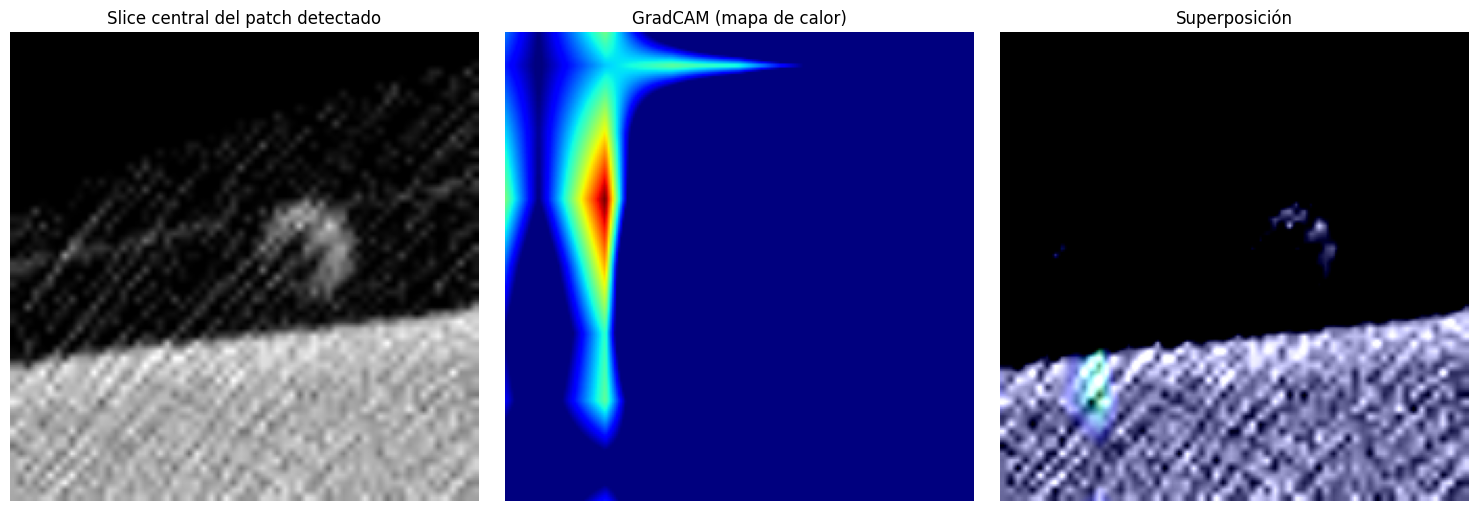


 Imagen guardada como gradcam_sliding_1.3.6.1.4.1.14519.5.2.1.6279.6001.144883090372691745980459537053.png


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np
import cv2
import SimpleITK as sitk
import matplotlib.pyplot as plt
from skimage.transform import resize
POSITIVAS_LISTA = "C:/CAPSTONE/2_TOMOGRAFIAS_POR_PRUEBA/B_GradCAM/positivas.txt"

# ============================================
# 1. Definir arquitectura (debe ser idéntica a la entrenada)
# ============================================
class ResNet18LSTM(nn.Module):
    def __init__(self, num_classes=1, lstm_hidden=256, num_layers=2, dropout=0.2):
        super(ResNet18LSTM, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        self.lstm = nn.LSTM(in_features, lstm_hidden, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        features = self.resnet(x)
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(features)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output.squeeze(1)

# ============================================
# 2. Función para convertir patch a secuencia (exactamente igual al entrenamiento)
# ============================================
def patch_a_secuencia(patch, seq_len=16, target_size=(224, 224)):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    z_center = patch.shape[0] // 2
    total_slices = patch.shape[0]
    half_seq = seq_len // 2
    start_idx = max(0, z_center - half_seq)
    end_idx = min(total_slices, z_center + half_seq)
    indices = np.linspace(start_idx, end_idx - 1, seq_len).astype(int)

    sequence = []
    for z in indices:
        axial_slice = patch[z, :, :]
        axial_uint8 = (axial_slice * 255).astype(np.uint8)
        axial_resized = cv2.resize(axial_uint8, target_size, interpolation=cv2.INTER_LINEAR)
        axial_norm = axial_resized / 255.0
        slice_tensor = torch.from_numpy(axial_norm).float().unsqueeze(0)
        slice_tensor = slice_tensor.repeat(3, 1, 1)
        slice_tensor = normalize(slice_tensor)
        sequence.append(slice_tensor)
    return torch.stack(sequence, dim=0)

# ============================================
# 3. Función de detección por ventana deslizante (con NMS)
# ============================================
def sliding_window_deteccion(volume, model, step=48, patch_size=64,
                             threshold=0.5, iou_threshold=0.3, device='cpu'):
    z, y, x = volume.shape
    detecciones = []
    z_centers = range(patch_size//2, z - patch_size//2, step)
    y_centers = range(patch_size//2, y - patch_size//2, step)
    x_centers = range(patch_size//2, x - patch_size//2, step)
    total = len(z_centers) * len(y_centers) * len(x_centers)
    print(f"   Ventanas a evaluar: {total}")

    for zc in z_centers:
        for yc in y_centers:
            for xc in x_centers:
                patch_hu = volume[zc - patch_size//2 : zc + patch_size//2,
                                  yc - patch_size//2 : yc + patch_size//2,
                                  xc - patch_size//2 : xc + patch_size//2].astype(np.float32)
                if patch_hu.shape != (patch_size, patch_size, patch_size):
                    continue
                # Clipping HU y normalización a [0,1] (igual que en entrenamiento)
                patch_clipped = np.clip(patch_hu, -1000, 400)
                patch_norm = (patch_clipped + 1000) / 1400.0
                # Convertir a secuencia
                seq = patch_a_secuencia(patch_norm)
                input_tensor = seq.unsqueeze(0).to(device)
                with torch.no_grad():
                    prob = torch.sigmoid(model(input_tensor)).item()
                if prob > threshold:
                    detecciones.append({'centro': (zc, yc, xc), 'prob': prob})

    # Non‑Maximum Suppression (NMS)
    if not detecciones:
        return []
    detecciones.sort(key=lambda x: x['prob'], reverse=True)
    kept = []
    for d in detecciones:
        keep = True
        for k in kept:
            iou = calcular_iou(d['centro'], k['centro'], patch_size)
            if iou > iou_threshold:
                keep = False
                break
        if keep:
            kept.append(d)
    return kept

def calcular_iou(c1, c2, tamanio):
    x1_min, x1_max = c1[2] - tamanio//2, c1[2] + tamanio//2
    y1_min, y1_max = c1[1] - tamanio//2, c1[1] + tamanio//2
    z1_min, z1_max = c1[0] - tamanio//2, c1[0] + tamanio//2

    x2_min, x2_max = c2[2] - tamanio//2, c2[2] + tamanio//2
    y2_min, y2_max = c2[1] - tamanio//2, c2[1] + tamanio//2
    z2_min, z2_max = c2[0] - tamanio//2, c2[0] + tamanio//2

    inter_x = max(0, min(x1_max, x2_max) - max(x1_min, x2_min))
    inter_y = max(0, min(y1_max, y2_max) - max(y1_min, y2_min))
    inter_z = max(0, min(z1_max, z2_max) - max(z1_min, z2_min))
    inter = inter_x * inter_y * inter_z

    vol = tamanio**3
    union = 2*vol - inter
    return inter / union if union > 0 else 0

# ============================================
# 4. Función para generar GradCAM sobre un patch
# ============================================
def generar_gradcam_patch(model, patch_norm, target_layer, device):
    seq = patch_a_secuencia(patch_norm)
    input_tensor = seq.unsqueeze(0).to(device)

    activations, gradients = None, None

    def save_activation(module, input, output):
        nonlocal activations
        activations = output.detach()

    def save_gradient(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0].detach()

    hook_fwd = target_layer.register_forward_hook(save_activation)
    hook_bwd = target_layer.register_full_backward_hook(save_gradient)

    output = model(input_tensor)
    model.zero_grad()
    output.backward()

    hook_fwd.remove()
    hook_bwd.remove()

    # ===== CAM ESTABLE =====
    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1)

    cam = cam[0]  # elimina batch SIEMPRE
    cam = cam.cpu().numpy()

    # asegurar 2D real
    cam = np.squeeze(cam)
    if cam.ndim != 2:
        cam = cam.mean(axis=0)

    slice_central = seq[seq.shape[0] // 2, 0].cpu().numpy()

    heatmap = resize(cam, slice_central.shape, anti_aliasing=True)

    heatmap = np.clip(heatmap, 0, None)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    heatmap_colored = plt.cm.jet(heatmap)[..., :3].astype(np.float32)

    img_3c = np.stack([slice_central] * 3, axis=-1).astype(np.float32)

    overlay = np.clip(0.6 * img_3c + 0.4 * heatmap_colored, 0, 1)

    return slice_central, heatmap, overlay

# ============================================
# 5. Cargar modelo y configurar dispositivo
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18LSTM().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Modelo cargado en {device}")

# ============================================
# 6. Seleccionar una tomografía de validación positiva (la primera de la lista)
# ============================================
with open(POSITIVAS_LISTA, "r") as f:
    tomos_pos = [line.strip() for line in f if line.strip()]
seriesuid = tomos_pos[0]   # primera tomografía positiva
mhd_path = encontrar_tomografia(seriesuid)   # función que ya tienes
if mhd_path is None:
    raise FileNotFoundError(f"No se encontró {seriesuid} en {DATA_PATH}")

print(f"\nProcesando tomografía: {seriesuid}")
print(f"   Archivo: {mhd_path}")

# Cargar volumen completo (valores HU originales)
sitk_img = sitk.ReadImage(mhd_path)
volume_hu = sitk.GetArrayFromImage(sitk_img).astype(np.float32)
print(f"   Volumen shape: {volume_hu.shape}")

# ============================================
# 7. Ejecutar sliding window (usando un umbral de 0.5)
# ============================================
print("\nEjecutando ventana deslizante (step=48, threshold=0.5)...")
detecciones = sliding_window_deteccion(volume_hu, model, step=48, threshold=0.5,
                                       iou_threshold=0.3, device=device)
print(f"Detecciones encontradas tras NMS: {len(detecciones)}")

if not detecciones:
    print("No se encontraron detecciones. Prueba a bajar el threshold o reducir el step.")
else:
    # Ordenar por probabilidad descendente
    detecciones.sort(key=lambda x: x['prob'], reverse=True)
    print("\nTop 3 detecciones:")
    for i, det in enumerate(detecciones[:3]):
        print(f"   {i+1}: centro={det['centro']}, prob={det['prob']:.4f}")

    # ============================================
    # 8. Generar GradCAM para la mejor detección
    # ============================================
    best = detecciones[0]
    zc, yc, xc = best['centro']
    print(f"\nMejor detección en coordenadas voxel: ({zc}, {yc}, {xc}) con prob={best['prob']:.4f}")

    # Extraer el patch correspondiente (sin normalización aquí, solo para visualizar)
    half = 32
    patch_hu = volume_hu[zc-half:zc+half, yc-half:yc+half, xc-half:xc+half].astype(np.float32)
    # Clipping y normalización
    patch_clipped = np.clip(patch_hu, -1000, 400)
    patch_norm = (patch_clipped + 1000) / 1400.0

    # Capa objetivo para GradCAM (última capa convolucional de ResNet)
    target_layer = model.resnet.layer4[-1].conv2

    slice_original, heatmap, overlay = generar_gradcam_patch(model, patch_norm, target_layer, device)

    # Mostrar resultados
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(slice_original, cmap='gray')
    axes[0].set_title('Slice central del patch detectado')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM (mapa de calor)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Superposición')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f"gradcam_sliding_{seriesuid}.png", dpi=150)
    plt.show()
    print(f"\n Imagen guardada como gradcam_sliding_{seriesuid}.png")